<a href="https://colab.research.google.com/github/Dass-19/LTSF/blob/main/LTSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [2]:
%matplotlib inline

In [3]:
np.random.seed(67)

# Resumen del paper

# Dataset

In [45]:
ETTh1 = pd.read_csv("https://raw.githubusercontent.com/zhouhaoyi/ETDataset/refs/heads/main/ETT-small/ETTh1.csv")

In [46]:
ETTh1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    17420 non-null  object 
 1   HUFL    17420 non-null  float64
 2   HULL    17420 non-null  float64
 3   MUFL    17420 non-null  float64
 4   MULL    17420 non-null  float64
 5   LUFL    17420 non-null  float64
 6   LULL    17420 non-null  float64
 7   OT      17420 non-null  float64
dtypes: float64(7), object(1)
memory usage: 1.1+ MB


In [47]:
ETTh1['date'] = pd.to_datetime(ETTh1['date'])

In [48]:
ETTh1.head()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


In [49]:
ETTh1.isnull().sum()

,0
date,0
HUFL,0
HULL,0
MUFL,0
MULL,0
LUFL,0
LULL,0
OT,0


In [50]:
ETTh1.describe()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
count,17420,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000
mean,2017-06-28 21:30:00,7.375141,2.242242,4.300239,0.881568,3.066062,0.856932,13.324672
min,2016-07-01 00:00:00,-22.705999,-4.756000,-25.087999,-5.934000,-1.188000,-1.371000,-4.080000
25%,2016-12-29 10:45:00,5.827000,0.737000,3.296000,-0.284000,2.315000,0.670000,6.964000
50%,2017-06-28 21:30:00,8.774000,2.210000,5.970000,0.959000,2.833000,0.975000,11.396000
75%,2017-12-27 08:15:00,11.788000,3.684000,8.635000,2.203000,3.625000,1.218000,18.079000
max,2018-06-26 19:00:00,23.643999,10.114000,17.341000,7.747000,8.498000,3.046000,46.007000
std,NaN,7.067744,2.042342,6.826978,1.809293,1.164506,0.599552,8.566946


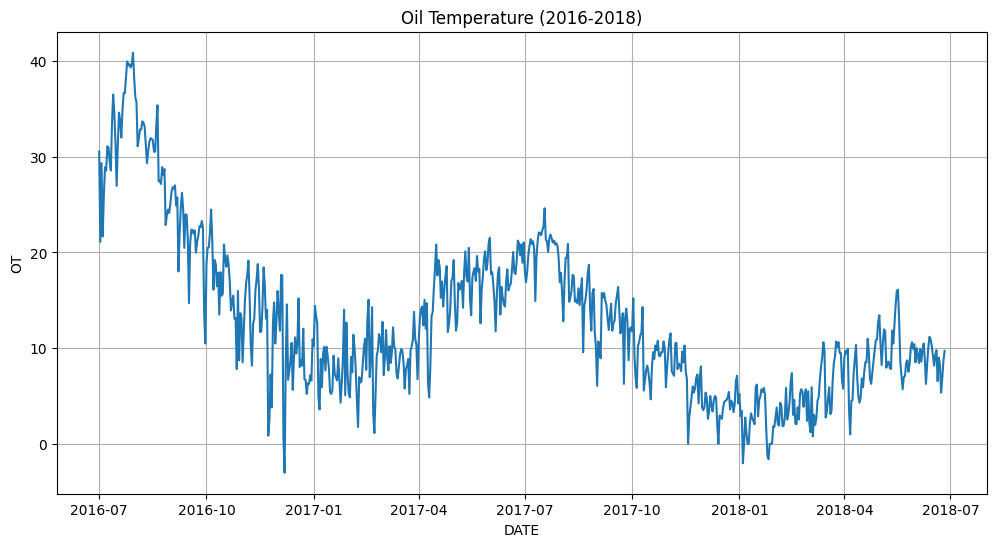

In [70]:
ETTh1.index = ETTh1.date
ETTh1_D = ETTh1.asfreq('D').dropna()
plt.figure(figsize=(12, 6))
plt.plot(ETTh1_D.OT)
plt.title('Oil Temperature (2016-2018)')
plt.xlabel('DATE')
plt.ylabel('OT')
plt.grid()

In [71]:
ETTh1_D['OT_5'] = ETTh1_D['OT'].rolling(window=5).mean()
ETTh1_D['OT_15'] = ETTh1_D['OT'].rolling(window=15).mean()

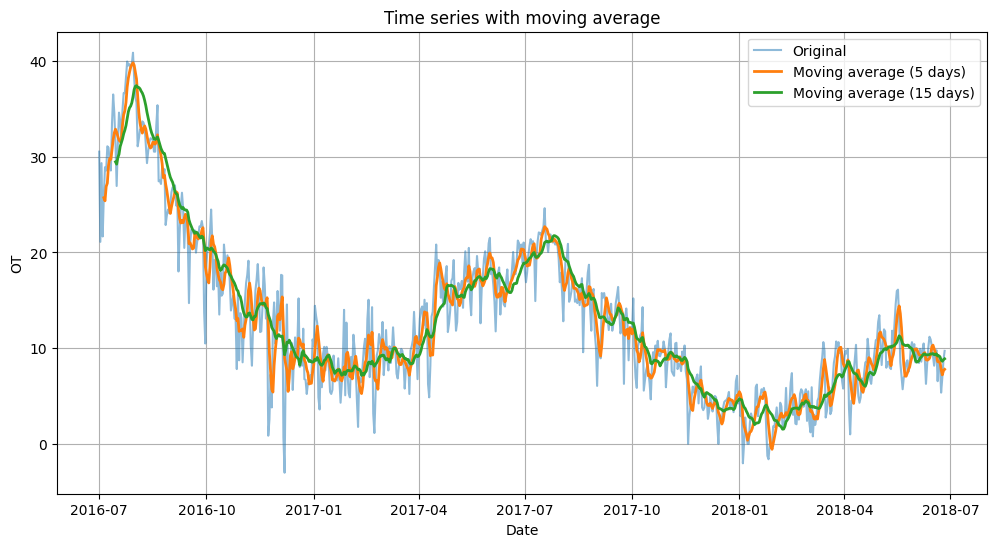

In [74]:
plt.figure(figsize=(12, 6))
plt.plot(ETTh1_D['OT'], label='Original', alpha=0.5)
plt.plot(ETTh1_D['OT_5'], label='Moving average (5 days)', linewidth=2)
plt.plot(ETTh1_D['OT_15'], label='Moving average (15 days)', linewidth=2)
plt.title('Time series with moving average')
plt.xlabel('Date')
plt.ylabel('OT')
plt.legend()
plt.grid()

In [75]:
ETTh1_D.head()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT,OT_5,OT_15
date,,,,,,,,,,
2016-07-01,2016-07-01,5.827,2.009,1.599,0.462,4.203,1.340,30.531000,NaN,NaN
2016-07-02,2016-07-02,5.224,3.081,2.701,1.315,2.437,1.523,21.104000,NaN,NaN
2016-07-03,2016-07-03,10.382,5.425,7.604,2.310,2.955,1.675,29.334999,NaN,NaN
2016-07-04,2016-07-04,9.913,5.894,6.254,2.630,3.015,1.858,21.667000,NaN,NaN
2016-07-05,2016-07-05,11.989,5.626,8.777,2.949,3.198,1.980,25.958000,25.719,NaN


In [76]:
decomposition = seasonal_decompose(ETTh1['OT'], model='additive', period=2160)

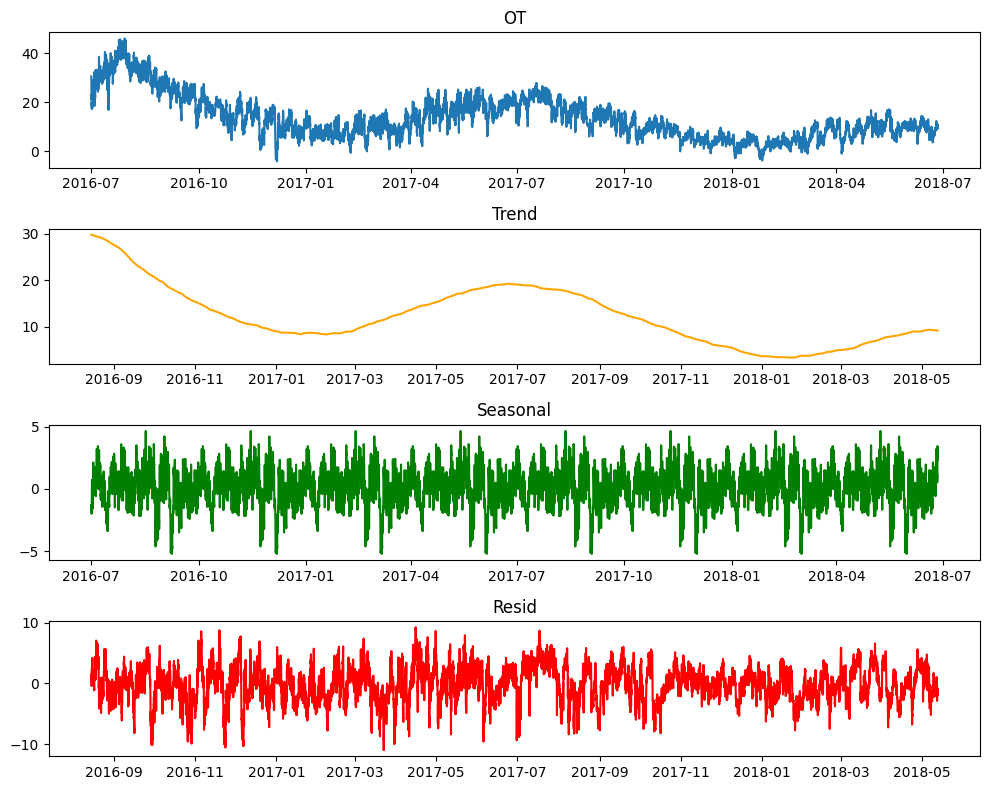

In [77]:
plt.figure(figsize=(10, 8))

plt.subplot(4, 1, 1)
plt.plot(ETTh1['OT'])
plt.title("OT")

plt.subplot(4, 1, 2)
plt.plot(decomposition.trend, color='orange')
plt.title("Trend")

plt.subplot(4, 1, 3)
plt.plot(decomposition.seasonal, color='green')
plt.title("Seasonal")

plt.subplot(4, 1, 4)
plt.plot(decomposition.resid, color='red')
plt.title("Resid")

plt.tight_layout()
plt.show()

# Implementación

In [2]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, output_size)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        lstm_out, (h, c) = self.lstm(x)
        # Tomar último estado
        last_hidden = h[-1]  # (batch, hidden_size)
        out = self.fc(self.drop(last_hidden))
        return out

In [ ]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size,
                 dropout=0.3, lr=1e-3):
        super().__init__()

        # Parámetros
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.output_size = output_size
        self.lr = lr

        # Capas
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, output_size)
        self.drop = nn.Dropout(dropout)

        # Loss y optimizer
        self.criterion = nn.MSELoss()
        self.optimizer = optim.Adam(self.parameters(), lr=lr)

        # Tracking
        self.train_losses = []
        self.val_losses = []

    def forward(self, x):
        """
        x: (batch, seq_len, input_size)
        return: (batch, output_size)
        """
        lstm_out, (h, c) = self.lstm(x)
        last_hidden = h[-1]  # (batch, hidden_size)
        out = self.fc(self.drop(last_hidden))
        return out

    def train_epoch(self, train_loader):
        """Entrena un epoch."""
        self.train()
        epoch_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.cuda()
            y_batch = y_batch.cuda()

            # Forward
            pred = self(X_batch)
            loss = self.criterion(pred, y_batch)

            # Backward
            self.optimizer.zero_grad()
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=5.0)

            self.optimizer.step()
            epoch_loss += loss.item()

        return epoch_loss / len(train_loader)

    def validate(self, val_loader):
        """Valida el modelo."""
        self.eval()
        val_loss = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.cuda()
                y_batch = y_batch.cuda()

                pred = self(X_batch)
                loss = self.criterion(pred, y_batch)
                val_loss += loss.item()

        return val_loss / len(val_loader)

    def fit(self, X_train, y_train, X_val, y_val, epochs=50, batch_size=32, verbose=True):
        """
        Entrena el modelo.

        Args:
            X_train: (n_samples, seq_len, input_size)
            y_train: (n_samples, output_size)
            X_val: (n_samples, seq_len, input_size)
            y_val: (n_samples, output_size)
            epochs: número de epochs
            batch_size: tamaño del batch
            verbose: print info cada epoch
        """
        # Crear dataloaders
        train_data = TensorDataset(
            torch.from_numpy(X_train),
            torch.from_numpy(y_train)
        )
        val_data = TensorDataset(
            torch.from_numpy(X_val),
            torch.from_numpy(y_val)
        )

        train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_data, batch_size=batch_size)

        # Mover modelo a GPU
        self.cuda()

        print("=" * 70)
        print("ENTRENAMIENTO")
        print("=" * 70)
        print(f"Epochs: {epochs}")
        print(f"Batch size: {batch_size}")
        print(f"Learning rate: {self.lr}")
        print(f"Loss: MSELoss")
        print(f"Optimizer: Adam")
        print(f"Gradient clipping: max_norm=5.0")
        print("=" * 70 + "\n")

        for epoch in range(epochs):
            # Train
            train_loss = self.train_epoch(train_loader)

            # Validate
            val_loss = self.validate(val_loader)

            # Tracking
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)

            # Print
            if verbose and (epoch + 1) % max(1, epochs // 10) == 0:
                print(f"Epoch {epoch+1:3d}/{epochs} | "
                      f"Train Loss: {train_loss:.6f} | "
                      f"Val Loss: {val_loss:.6f}")

        print("\n✓ Entrenamiento completado\n")

    def predict(self, X):
        """
        Predice sobre datos nuevos.

        Args:
            X: (n_samples, seq_len, input_size)

        Returns:
            predicciones: (n_samples, output_size)
        """
        self.eval()
        X = torch.from_numpy(X).cuda()

        with torch.no_grad():
            pred = self(X)

        return pred.cpu().numpy()

    def plot_losses(self):
        """Grafica train vs val loss."""
        plt.figure(figsize=(10, 5))
        plt.plot(self.train_losses, label='Train Loss', linewidth=2)
        plt.plot(self.val_losses, label='Val Loss', linewidth=2)
        plt.xlabel('Epoch')
        plt.ylabel('Loss (MSE)')
        plt.title('Training vs Validation Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

# Entrenamiento y evaluación

 # Análisis crítico

# Conclusiones